<a href="https://colab.research.google.com/github/AMujahid843/STQD6134-Business-Analytics/blob/main/STQD6134_GroupA_Project1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**STQD6134 : Business Analytics Project 1 - Group A**

Scenario:
You are a Business Analyst at Streamify, a digital streaming company that offers on-demand video content through monthly and yearly subscriptions.

Problem Statement:

1. To  understand how different customer segments and subscription plans affect revenue and customer retention

2. To perform an analysis on subscription data from the last year and provide insights on:

  *   Subscription and cancellation trends
  *   Revenue performance by plan type and region
  *   Customer engagement metrics

## Data Simulation

In [ ]:
# Data simulation, to generate dataset with sample size 2000

# We adding set.seed() for repeatable results
set.seed(15)

# Sample size
n <- 2000

# Attributes
## CustomerID
CustomerID <- paste0("C", sprintf("%04d", 1:n))

## Join Dates
JoinDate <- sample(seq(as.Date('2024-01-01'),as.Date('2024-12-31'), by="day"), n, replace = TRUE)

## Active Months
ActiveMonths <- sample(1:12, n, replace = TRUE)

library(dplyr)

## Cancellation dates (25% cancellation)
CancelDate <- if_else(runif(n) < 0.25, JoinDate + ActiveMonths*30, as.Date(NA))

## Region
Region <- sample(c("North", "South", "East", "West"), n, replace = TRUE)

## Subscription type & fees
SubscriptionType <- sample(c("Basic", "Standard", "Premium"), n, replace = TRUE, prob=c(0.4, 0.35, 0.25))
MonthlyFee <- ifelse(SubscriptionType == "Basic", 10,
                     ifelse(SubscriptionType == "Standard", 20, 30))

## Total streams
TotalStreams <- round(rnorm(n, mean=170, sd=60))
TotalStreams <- pmax(TotalStreams,0)  #total stream starts from 0,  no negative value

## Device type & payment method
DeviceType <- sample(c("Mobile", "Smart TV", "Laptop", "Tablet"), n, replace = TRUE)
PaymentMethod <- sample(c("Card", "E-Wallet", "OnlineBanking"), n, replace = TRUE)

## Stream Dataframe
stream_data <- data.frame(CustomerID, JoinDate, CancelDate, Region, SubscriptionType, MonthlyFee,
                          ActiveMonths, TotalStreams, DeviceType, PaymentMethod)

## Revenue
stream_data$Revenue <- stream_data$MonthlyFee * stream_data$ActiveMonths
head(stream_data)

## Save to CSV file
write.csv(stream_data, "stream_data.csv", row.names = FALSE)  #simulated dataset
getwd()


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




,CustomerID,JoinDate,CancelDate,Region,SubscriptionType,MonthlyFee,ActiveMonths,TotalStreams,DeviceType,PaymentMethod,Revenue
,<chr>,<date>,<date>,<chr>,<chr>,<dbl>,<int>,<dbl>,<chr>,<chr>,<dbl>
1,C0001,2024-02-06,NA,East,Basic,10,5,116,Smart TV,Card,50
2,C0002,2024-12-27,NA,West,Standard,20,8,206,Mobile,Card,160
3,C0003,2024-06-10,NA,North,Basic,10,5,227,Smart TV,Card,50
4,C0004,2024-10-20,2025-07-17,South,Basic,10,9,185,Laptop,Card,90
5,C0005,2024-06-25,NA,West,Premium,30,6,252,Smart TV,E-Wallet,180
6,C0006,2024-09-17,NA,East,Premium,30,6,103,Mobile,E-Wallet,180


[1] "/content"

## 1. Data Preprocessing

In [ ]:
stream_data <- read.csv("stream_data.csv", header=TRUE, stringsAsFactors=TRUE)
head(stream_data)
summary(stream_data)

#Task 1 - Preprocessing

#check & handle missing value
na_counts <- colSums(is.na(stream_data))
print("NA counts before CancelDate replacement:")
print(na_counts)

stream_data$CancelDate <- as.Date((stream_data$CancelDate))
stream_data$CancelDate[is.na(stream_data$CancelDate)] <- as.Date("2030-12-31") #replace NA with future date #change data type to Date
na_counts <- colSums(is.na(stream_data))
print("NA counts after CancelDate replacement:")
print(na_counts)

#convert data type
print("Structure before JoinDate & SubscriptionType conversion:")
str(stream_data)
stream_data$JoinDate <- as.Date(stream_data$JoinDate, origin = "1970-01-01")  #change the data type to Date


#change data type of Subscription Type to ordinal factor
stream_data$SubscriptionType <- factor(stream_data$SubscriptionType, order=TRUE, levels = c("Basic", "Standard", "Premium"))
print("Structure after JoinDate & SubscriptionType conversion:")
str(stream_data)

#create new variables
stream_data$IsActive <- stream_data$CancelDate == as.Date("2030-12-31")  #TRUE if CancelDate=NA which have been replaced by FutureDate
library(lubridate)
stream_data$MonthJoined <- month(stream_data$JoinDate, label = TRUE, abbr = TRUE)  #return Months in Mmm format in order.

#head(stream_data)
print("Final structure of stream_data:")
str(stream_data)

,CustomerID,JoinDate,CancelDate,Region,SubscriptionType,MonthlyFee,ActiveMonths,TotalStreams,DeviceType,PaymentMethod,Revenue
,<fct>,<fct>,<fct>,<fct>,<fct>,<int>,<int>,<int>,<fct>,<fct>,<int>
1,C0001,2024-02-06,NA,East,Basic,10,5,116,Smart TV,Card,50
2,C0002,2024-12-27,NA,West,Standard,20,8,206,Mobile,Card,160
3,C0003,2024-06-10,NA,North,Basic,10,5,227,Smart TV,Card,50
4,C0004,2024-10-20,2025-07-17,South,Basic,10,9,185,Laptop,Card,90
5,C0005,2024-06-25,NA,West,Premium,30,6,252,Smart TV,E-Wallet,180
6,C0006,2024-09-17,NA,East,Premium,30,6,103,Mobile,E-Wallet,180


   CustomerID         JoinDate         CancelDate     Region   
 C0001  :   1   2024-06-24:  11   2024-09-03:   6   East :505  
 C0002  :   1   2024-07-06:  11   2025-05-29:   5   North:518  
 C0003  :   1   2024-10-01:  11   2024-09-19:   4   South:473  
 C0004  :   1   2024-03-04:  10   2024-10-27:   4   West :504  
 C0005  :   1   2024-03-15:  10   2024-11-25:   4              
 C0006  :   1   2024-03-23:  10   (Other)   : 478              
 (Other):1994   (Other)   :1937   NA's      :1499              
 SubscriptionType   MonthlyFee     ActiveMonths     TotalStreams  
 Basic   :784     Min.   :10.00   Min.   : 1.000   Min.   :  0.0  
 Premium :540     1st Qu.:10.00   1st Qu.: 3.000   1st Qu.:130.0  
 Standard:676     Median :20.00   Median : 6.000   Median :171.0  
                  Mean   :18.78   Mean   : 6.421   Mean   :169.8  
                  3rd Qu.:30.00   3rd Qu.: 9.000   3rd Qu.:212.0  
                  Max.   :30.00   Max.   :12.000   Max.   :390.0  
                   

[1] "NA counts before CancelDate replacement:"
      CustomerID         JoinDate       CancelDate           Region 
               0                0             1499                0 
SubscriptionType       MonthlyFee     ActiveMonths     TotalStreams 
               0                0                0                0 
      DeviceType    PaymentMethod          Revenue 
               0                0                0 
[1] "NA counts after CancelDate replacement:"
      CustomerID         JoinDate       CancelDate           Region 
               0                0                0                0 
SubscriptionType       MonthlyFee     ActiveMonths     TotalStreams 
               0                0                0                0 
      DeviceType    PaymentMethod          Revenue 
               0                0                0 
[1] "Structure before JoinDate & SubscriptionType conversion:"
'data.frame':	2000 obs. of  11 variables:
 $ CustomerID      : Factor w/ 2000 levels


Attaching package: ‘lubridate’


The following objects are masked from ‘package:base’:

    date, intersect, setdiff, union




[1] "Final structure of stream_data:"
'data.frame':	2000 obs. of  13 variables:
 $ CustomerID      : Factor w/ 2000 levels "C0001","C0002",..: 1 2 3 4 5 6 7 8 9 10 ...
 $ JoinDate        : Date, format: "2024-02-06" "2024-12-27" ...
 $ CancelDate      : Date, format: "2030-12-31" "2030-12-31" ...
 $ Region          : Factor w/ 4 levels "East","North",..: 1 4 2 3 4 1 4 2 3 3 ...
 $ SubscriptionType: Ord.factor w/ 3 levels "Basic"<"Standard"<..: 1 2 1 1 3 3 1 1 2 1 ...
 $ MonthlyFee      : int  10 20 10 10 30 30 10 10 20 10 ...
 $ ActiveMonths    : int  5 8 5 9 6 6 10 10 3 7 ...
 $ TotalStreams    : int  116 206 227 185 252 103 255 168 127 188 ...
 $ DeviceType      : Factor w/ 4 levels "Laptop","Mobile",..: 3 2 3 1 3 2 3 3 3 1 ...
 $ PaymentMethod   : Factor w/ 3 levels "Card","E-Wallet",..: 1 1 1 1 2 2 2 3 1 2 ...
 $ Revenue         : int  50 160 50 90 180 180 100 100 60 70 ...
 $ IsActive        : logi  TRUE TRUE TRUE FALSE TRUE TRUE ...
 $ MonthJoined     : Ord.factor w/ 12 levels "J

## 2. Business Metric Calculations

In [ ]:
## (1.) Total Revenue - Total Revenue generated during the year.

TotalRevenue <- sum(stream_data$Revenue, na.rm = TRUE)
TotalRevenue

[1] 242910

In [ ]:
## (2.) Average Revenue per User (ARPU) – Average revenue per customer.

ARPU <- mean(stream_data$Revenue, na.rm = TRUE)
ARPU

[1] 121.455

In [ ]:
## (3.) Revenue by Subscription Type - Compare revenue generated by Basic, Standard, and Premium Plans.

RevenueByType <- aggregate(Revenue ~ SubscriptionType,
                           data = stream_data, sum)
RevenueByType

SubscriptionType,Revenue
<ord>,<int>
Basic,49360
Standard,87320
Premium,106230


In [ ]:
## (4.) Churn Rate - % of customers who cancelled during the year.

ChurnRate <- (sum(stream_data$IsActive == FALSE) / nrow(stream_data))*100
ChurnRate

[1] 25.05

In [ ]:
## (5.) Regional Revenue - Total revenue by region.

RegionalRevenue <- aggregate(Revenue ~ Region,
                             data = stream_data, sum)
RegionalRevenue

Region,Revenue
<fct>,<int>
East,62320
North,64010
South,56700
West,59880


In [ ]:
## (6.) Average Engagement (Streams per Active Month)
## - Average number of videos watched per month by customers.

stream_data$Engagement <- stream_data$TotalStreams / stream_data$ActiveMonths
AvgEngagement <- mean(stream_data$Engagement, na.rm = TRUE)
AvgEngagement

[1] 44.47467

In [ ]:
## (7.) Monthly Join Trend - Number of new customers joining per months.

MonthlyJoinTrend <- as.data.frame(table(format(stream_data$JoinDate, "%m")))
MonthlyJoinTrend

Var1,Freq
<fct>,<int>
01,172
02,155
03,179
04,166
05,172
06,178
07,188
08,162
09,162


In [ ]:
## (8.) Device Usage Breakdown - Most common devices used to access the platform.

DeviceUsage <- as.data.frame(table(stream_data$DeviceType))
DeviceUsage

Var1,Freq
<fct>,<int>
Laptop,515
Mobile,495
Smart TV,496
Tablet,494


## 3. Visualization

In [ ]:
library(ggplot2) #Load library to plot visualization

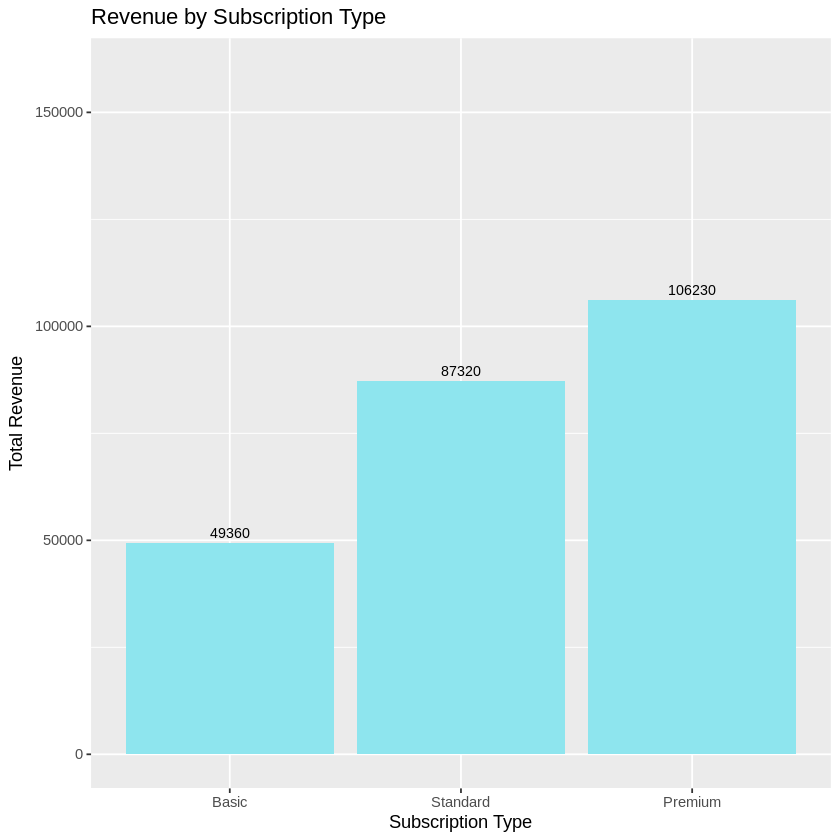

In [ ]:
# Use bar graph to compare categorical data
# x-axis : Subscription Type, y-axis : Total Revenue
# Answers: Which subscription plan generates the most revenue?

ggplot(RevenueByType, aes(x = factor(SubscriptionType, levels = c("Basic", "Standard", "Premium")), y = Revenue)) +
  geom_bar(stat = "identity", fill = "cadetblue2") +
  geom_text(aes(label = Revenue), vjust = -0.5, size = 3) +
  labs(title = "Revenue by Subscription Type", x = "Subscription Type", y = "Total Revenue") +
  coord_cartesian(ylim = c(0, max(RevenueByType$Revenue) * 1.5))

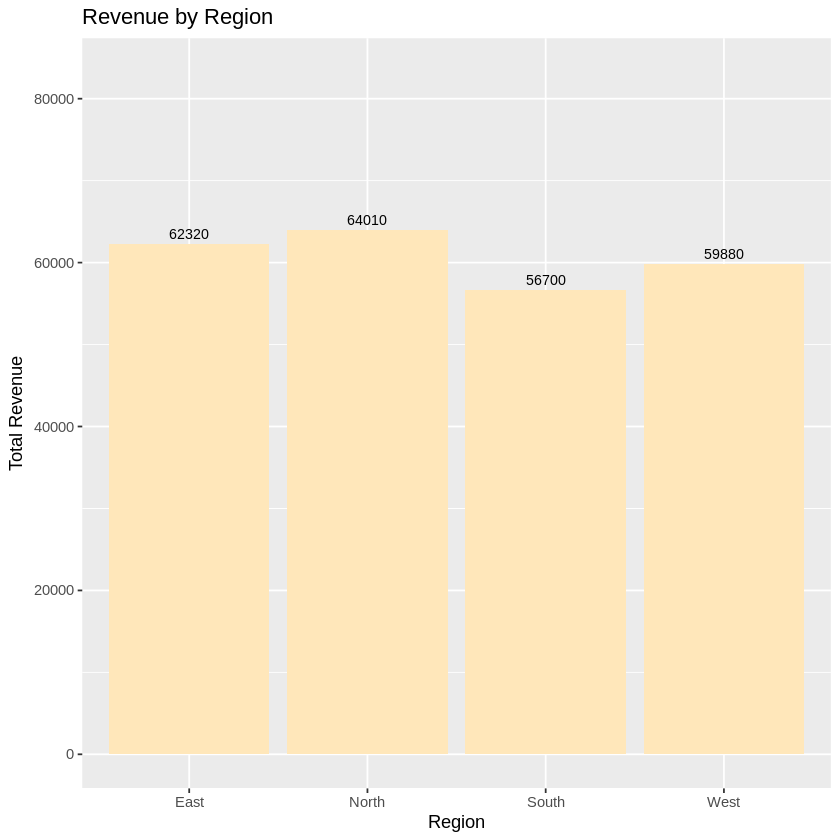

In [ ]:
# Revenue by Region
# Use bar graph to compare total revenue across regions, it highlights regional performance differences.
# Answer: Which region generates the most revenue?

ggplot(RegionalRevenue, aes(x = Region, y = Revenue)) +
  geom_bar(stat = "identity", fill = "wheat1") +
  geom_text(aes(label = Revenue), vjust = -0.5, size = 3) +
  labs(title = "Revenue by Region", x = "Region", y = "Total Revenue") +
  coord_cartesian(ylim = c(0, max(RegionalRevenue$Revenue) * 1.3))

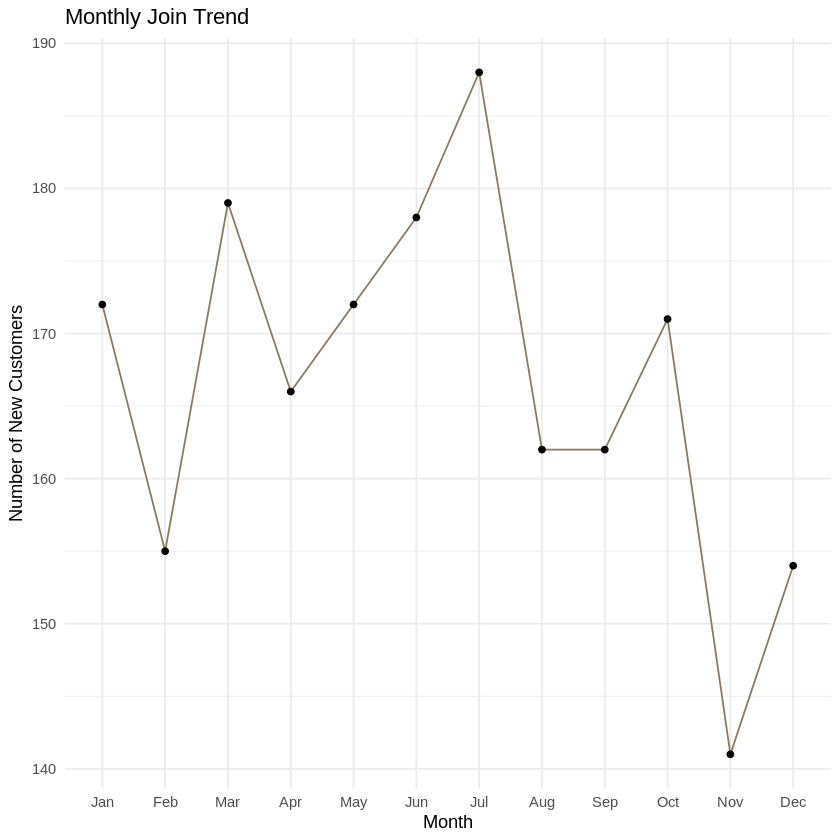

In [ ]:
# Monthly Join Trend
# Use line chart to show trends over time (months)

# Add new column for month labels and sort it by months instead of alphabetical orders
MonthlyJoinTrend$Month <- factor(MonthlyJoinTrend$Var1, levels = sprintf("%02d", 1:12), labels = month.abb)
# Plot x-axis: Month, y-axis: Number of new customers
ggplot(MonthlyJoinTrend, aes(x = Month, y = Freq, group = 1)) +
  geom_line(color = "navajowhite4") +
  geom_point() +
  labs(title = "Monthly Join Trend", x = "Month", y = "Number of New Customers") +
  theme_minimal()

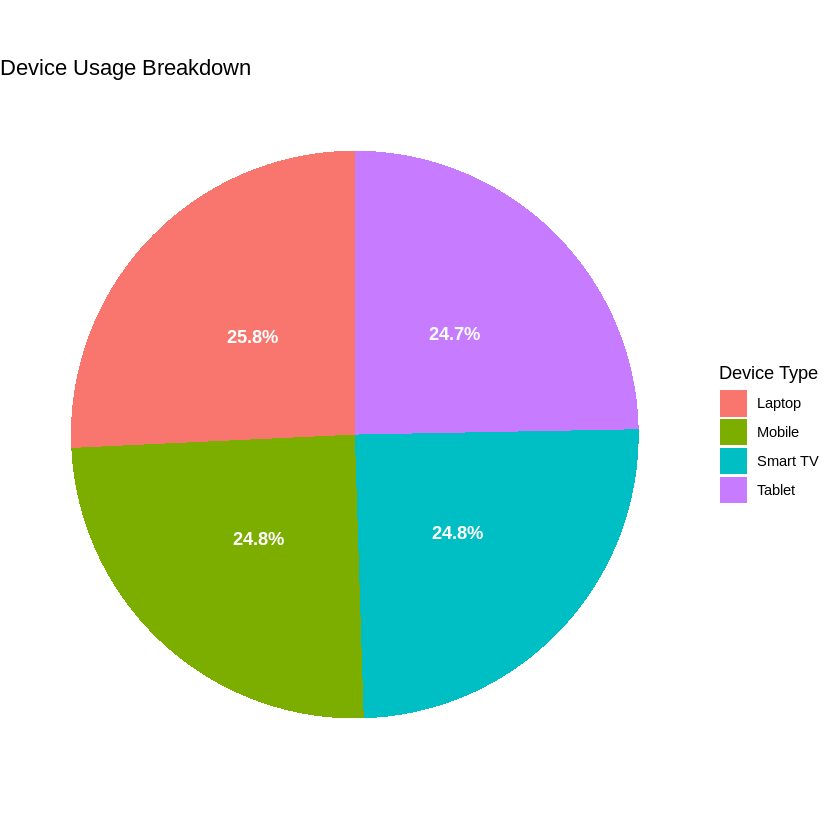

In [ ]:
# Device Usage
# Use Pie Chart to show proportions of categorical data
names(DeviceUsage) <- c("Device", "Count")
DeviceUsage$Percentage <- round((DeviceUsage$Count / sum(DeviceUsage$Count)) * 100, 1)

ggplot(DeviceUsage, aes(x = "", y = Count, fill = Device)) +
  geom_bar(stat = "identity", width = 1) +
  coord_polar("y", start = 0) +
  geom_text(aes(label = paste0(Percentage, "%")), position = position_stack(vjust = 0.5), color = "white", fontface = "bold") +
  labs(title = "Device Usage Breakdown", fill = "Device Type") +
  theme_void()


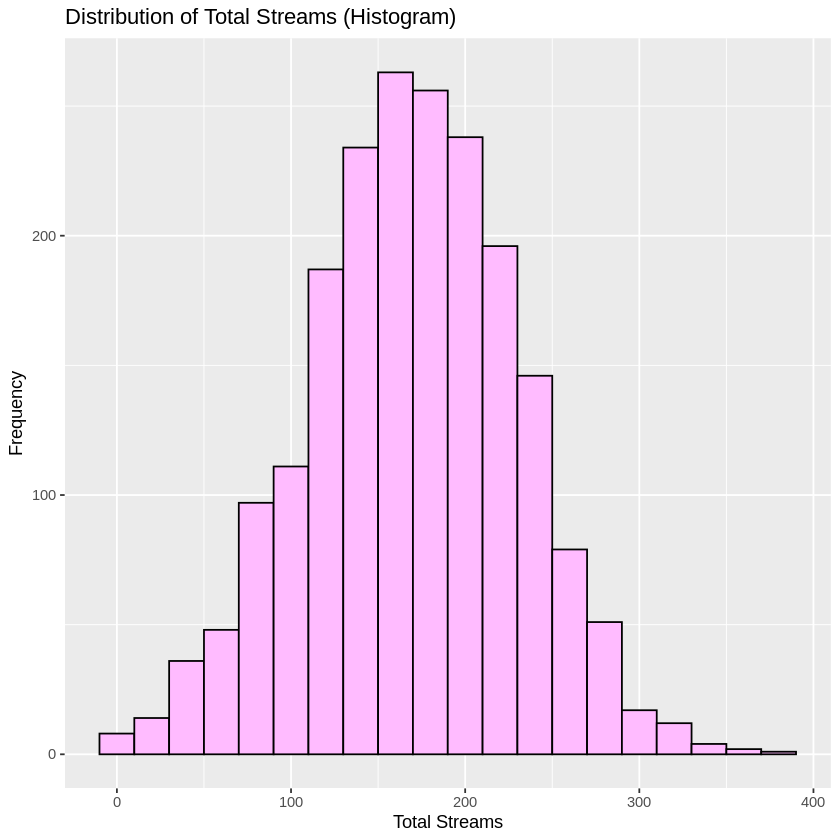

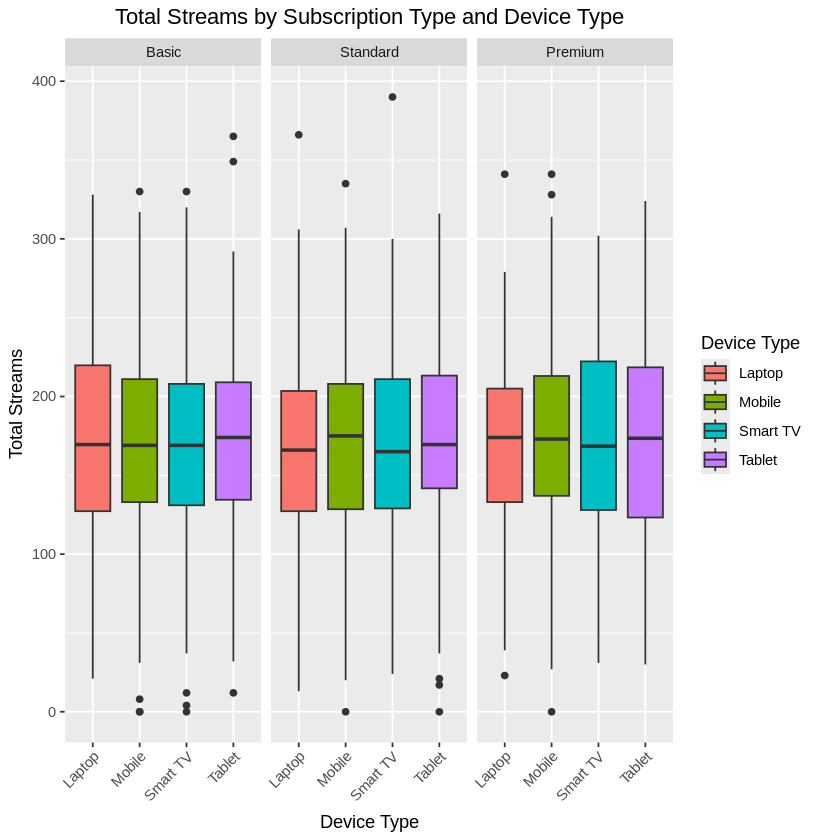

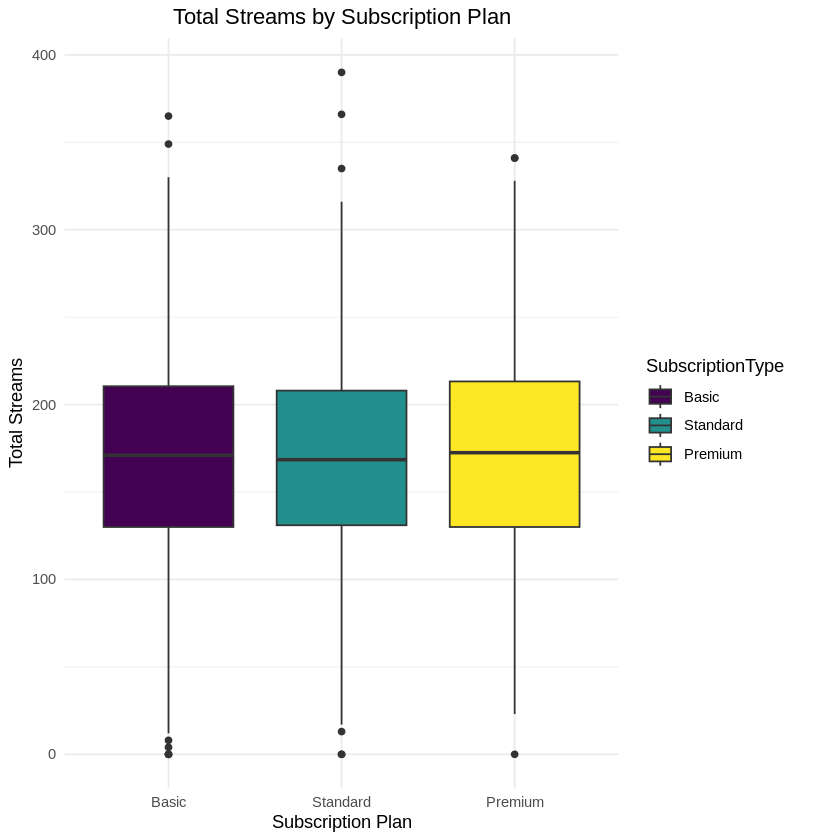

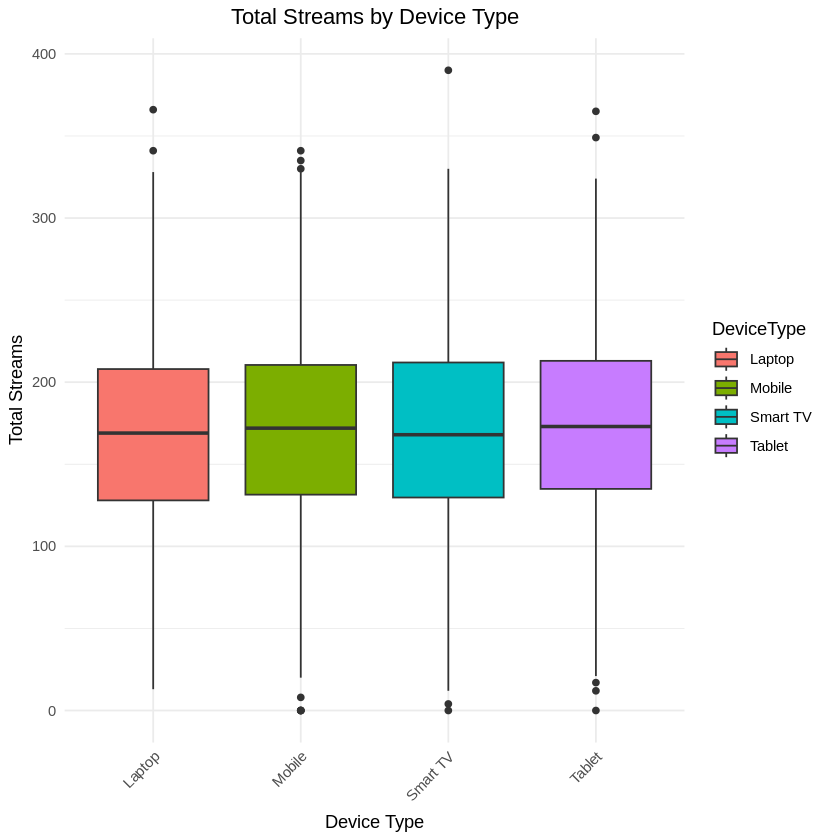

In [ ]:
# TotalStreams distribution (to show engagement)
# Answer Question : How do engagement levels vary across plans or devices?
# Use Histogram to show the distribution of TotalStreams

ggplot(stream_data, aes(x = TotalStreams)) +
  geom_histogram(binwidth = 20, fill = "plum1", color = "black") +
  labs(title = "Distribution of Total Streams (Histogram)", x = "Total Streams", y = "Frequency")

# Justification: We need to compare TotalStreams (continuous) across SubscriptionType (3 categories) and DeviceType (4 categories).
ggplot(stream_data, aes(x = DeviceType, y = TotalStreams, fill = DeviceType)) +
  geom_boxplot() +
  facet_wrap(~ SubscriptionType) +  # Facet by plan for clear separation
  labs(title = "Total Streams by Subscription Type and Device Type",
       x = "Device Type",
       y = "Total Streams",
       fill = "Device Type") +
  theme(plot.title = element_text(hjust = 0.5),
        axis.text.x = element_text(angle = 45, hjust = 1))  # Rotate x-labels for readability

# Total Streams by Subscription Plan
library(ggplot2)

ggplot(stream_data, aes(x = SubscriptionType, y = TotalStreams, fill = SubscriptionType)) +
  geom_boxplot() +
  labs(title = "Total Streams by Subscription Plan",
       x = "Subscription Plan",
       y = "Total Streams") +
  theme_minimal() +
  theme(plot.title = element_text(hjust = 0.5))

# Total Streams by Devices Type
ggplot(stream_data, aes(x = DeviceType, y = TotalStreams, fill = DeviceType)) +
  geom_boxplot() +
  labs(title = "Total Streams by Device Type",
       x = "Device Type",
       y = "Total Streams") +
  theme_minimal() +
  theme(plot.title = element_text(hjust = 0.5),
        axis.text.x = element_text(angle = 45, hjust = 1))

## 4. Insights and Recommendations

**Which subscription plan and region generate the most revenue?**
<p align="justify">
From the bar graph of “Revenue by Subscription Type” as shown in part 3, we can see that Premium plan generates the most revenue followed by Standard and Basic from the height of each bar. Premium plan generates specifically &#36;106230 compare to Standard and Basic which only generate &#36;87320 and &#36;49360 respectively based on table (3.) in part 2. Comparing across region, North region generates the most revenue followed by East, West and South as per the “Revenue by Region” bar graph. From the table (5.) in part 2, North region generates &#36;64010. East, West and South region meanwhile is not far off from North region with each of them contributes &#36;62320, &#36;59880 and &#36;56700 respectively towards Streamify’s revenue.  
</p>

**What is the overall churn rate and what does it suggest?**
<p align="justify">
The churn rate or the percentage of customers who cancelled Streamify’s plan during last year is 25.05% which compute around a quarter of the total customers. The number is a bit concerning and this needs to be addressed in order to reduce the rate in the future while attracting potential new customers.
</p>

**How do engagement levels (streams) vary across plans or devices?**
<p align="justify">
The engagement levels (streams) can be observed from the box plot "Total Streams by Subscription Type and Device Type" as shown in part 3. For the Basic plan, the third quartile and maximum value for laptop is the highest compare to three other devices suggest that users stream more videos on laptop. It may be due to the convenience that they might have by watching videos in a proper viewing set up (larger screen compare to mobile and tablet) and still able to watch it anywhere unlike the smart TV.
</p>
<p align="justify">
However, for Standard plan’s subscribers, the plot gives an insight that videos streamed on mobile and tablet are higher compare to laptop and smart TV as shown by the median, third quartile and the maximum values. The reason for this might be because Standard plan has more accessible videos compare to the Basic plan. Users have access to a large library of videos, and devices such as mobile phones and tablets offer greater mobility; letting them watch anywhere, anytime, unlike Smart TVs or laptops.
</p>
<p align="justify">
The trend changes for the Premium plan with stream volumes for smart TV increases as compared to the previous two plans. The third quartile of the smart TV is the highest followed by the tablet, mobile and the lowest is laptop. Premium plan is the highest tier plan which means; largest video library, no restriction (no ad in the videos), greater video quality with more features. Hence, smart TV provides the best option for binge watching, longer watching durations as well as the best viewing mode (bigger screen) in a home setting. That might be the reasons why the number of videos streamed is high for smart TV.
</p>

**Suggest 1–2 strategies to improve retention or increase revenue**
<p align="justify">
One of the ways that the company can improve retention is by improvising the user interface. This includes a clean interface, easy navigation and provide personalized recommendations based on the users’ watching history data.

Another way is by introducing a loyalty program; in which the users can enjoy a discounted monthly subscription fee for all plans if they stayed after a certain period of time (6 months or 1 year).

Besides, the number of new customers shows a reduction in Q3, indicating a slowdown in sales growth. This highlights potential weaknesses in the current marketing strategy. Hence, the strategy should be strengthened to attract new customers, drive revenue growth, and ensure a healthy sales pipeline.
</p>